In [71]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split

# Load and visualise the dataset - MNIST

In [72]:
np.random.seed(42)  # same random numbers every run

# Load MNIST
# Downloads ~12 MB the first time, cached afterwards
print('Loading MNIST...')
mnist   = fetch_openml('mnist_784', version=1, as_frame=False, parser='auto')
X_all   = mnist.data.astype(np.float32) / 255.0  # normalise pixels to [0, 1]
y_all   = mnist.target.astype(int)

# Use a subset of 10 000 for fast runs
# stratify=y ensures all 10 digit classes appear proportionally
X_sub, _, y_sub, _ = train_test_split(
    X_all, y_all, train_size=10_000, random_state=42, stratify=y_all
)

print(f'Subset shape : {X_sub.shape}   (10 000 samples × 784 pixels)')
print(f'Classes      : {np.unique(y_sub)}')

Loading MNIST...
Subset shape : (10000, 784)   (10 000 samples × 784 pixels)
Classes      : [0 1 2 3 4 5 6 7 8 9]


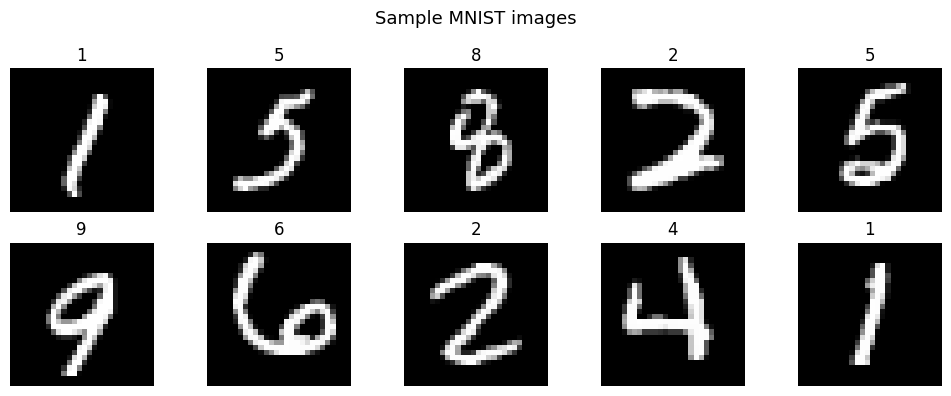

In [73]:
# Visualise a few samples
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(X_sub[i].reshape(28, 28), cmap='gray')
    ax.set_title(str(y_sub[i])); ax.axis('off')
plt.suptitle('Sample MNIST images', fontsize=13)
plt.tight_layout()
plt.show()

# Split the dataset

> When we train a model we need **three separate buckets** of data:
>
> | Split | Purpose |
> |---|---|
> | **Train** | The model learns from this — weights are updated on it |
> | **Validation** | We *watch* the model here during training — did it actually generalise? |
> | **Test** | Final score — sealed until the very end, never used for any decision |

>
> **One-hot encoding:** our labels are integers (0–9). The output layer produces 10 numbers.  
> We encode label `3` as `[0,0,0,1,0,0,0,0,0,0]` so we can compute cross-entropy loss directly.

In [74]:
# Split: 70% train, 15% val, 15% test
X_temp, X_test, y_temp, y_test = train_test_split(
    X_sub, y_sub, test_size=0.15, random_state=42, stratify=y_sub
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.15 / 0.85, random_state=42, stratify=y_temp
)

In [75]:
print(f'Train : {X_train.shape[0]:>5} samples')
print(f'Val   : {X_val.shape[0]:>5} samples')
print(f'Test  : {X_test.shape[0]:>5} samples')

Train :  7000 samples
Val   :  1500 samples
Test  :  1500 samples


In [76]:
# label k  →  a vector of zeros with a 1 in position k
def one_hot(y, n_classes=10):
    Y = np.zeros((len(y), n_classes))
    Y[np.arange(len(y)), y] = 1
    return Y

In [77]:
Y_train = one_hot(y_train)  # (7000, 10)
Y_val   = one_hot(y_val)    # (1500, 10)
Y_test  = one_hot(y_test)   # (1500, 10)

# Activation functions & Cross Entropy Loss

> - `relu` / `relu_grad` — activation and its derivative
> - `softmax` — turns raw scores into probabilities (needed for multi-class)
> - `cross_entropy_loss` — the right loss function when output is a probability distribution

ReLU: pass positives through, zero out negatives.

In [78]:
def relu(z):
    return np.maximum(0, z)

  Derivative of ReLU: 1 where z > 0, else 0

In [79]:
def relu_grad(z):
    return (z > 0).astype(float)

Softmax: converts raw scores into probabilities (positive, sum to 1).
Subtracting max(z) before exp() prevents numerical overflow — result is identical.


> **Key point about softmax + cross-entropy:**  
> When we differentiate softmax cross-entropy together, the gradient simplifies to just `(probs - Y) / n`.  
> That's why the output layer gradient in `backward()` looks so clean

In [80]:
def softmax(z):
    z_stable = z - np.max(z, axis=1, keepdims=True)
    exp_z    = np.exp(z_stable)
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)

  Cross-entropy loss for multi-class classification.
  
      probs : softmax output  (n, 10)  — predicted probabilities
      Y     : one-hot labels  (n, 10)  — true distribution
  
  Returns the average loss over the batch (a single scalar).

In [81]:
def cross_entropy_loss(probs, Y):
    n = Y.shape[0]
    return -np.sum(Y * np.log(probs + 1e-9)) / n  # 1e-9 avoids log(0)

# Our Neural Net

In [82]:
# two-hidden-layer fully connected network
# Arch: 784 -> h1 -> h2 -> 10 (classes)
# init_fn -> weight init
class NeuralNet:

  def __init__(self, input_size=784, h1=124, h2=64, output_size=10, init_fn=None):

    if init_fn is None:
      raise ValueError('Provide the init_fn: init_zero, init_random, init_xavier, or init_he')

    # init weights with the chosen strategy, biases start with 0
    self.W1 = init_fn((input_size, h1)); self.b1 = np.zeros((1, h1))
    self.W2 = init_fn((h1, h2)); self.b2 = np.zeros((1, h2))
    self.W3 = init_fn((h2, output_size)); self.b3 = np.zeros((1, output_size))

  def forward(self, X):
    # compute network output for input X
    # storing intermediate values Z1, A1 etc. needed by backward()

    # Layer 1: linear -> ReLU
    self.Z1 = X @ self.W1 + self.b1 # (n, h1); self.Z1 = np.dot(X, self.W1) + self.b1
    self.A1 = relu(self.Z1)

    # Layer 2: linear -> ReLU
    self.Z2 = self.A1 @ self.W2 + self.b2 # (n, h2)
    self.A2 = relu(self.Z2)

    # Output layer: linear -> softmax
    self.Z3 = self.A2 @ self.W3 + self.b3 # (n, 10) we have 10 classes 0-9 digits
    self.probs = softmax(self.Z3)

    return self.probs

  def backward(self, X, Y):
    # compute gradients of the cross-entropy loss w.r.t. all weigths/biases
    # chain rule applied layer by layer output -> input

    n = X.shape[0]

    # output layer gradient
    dZ3 = (self.probs - Y) / n
    self.dW3 = self.A2.T @ dZ3 # gradient w.r.t. W3
    self.db3 = dZ3.sum(axis=0, keepdims=True)

    # Layer 2 gradient - chain rule back through ReLU
    dA2 = dZ3 @ self.W3.T
    dZ2 = dA2 * relu_grad(self.Z2)
    self.dW2 = self.A1.T @ dZ2
    self.db2 = dZ2.sum(axis=0, keepdims=True)

    # Layer 1 gradient
    dA1 = dZ2 @ self.W2.T
    dZ1 = dA1 * relu_grad(self.Z1)
    self.dW1 = X.T @ dZ1
    self.db1 = dZ1.sum(axis=0, keepdims=True)

  # gardient descent update
  def update(self, lr):
    # move each weight one step in the direction that reduces loss
    self.W1 -= lr * self.dW1; self.b1 -= lr * self.db1
    self.W2 -= lr * self.dW2; self.b2 -= lr * self.db2
    self.W3 -= lr * self.dW3; self.b3 -= lr * self.db3

  # helper f-ns

  # return the predicted class index for each sample
  def predict(self, X):
    return np.argmax(self.forward(X), axis=1)

  def accuracy(self, X, y):
    return 100.0 * np.mean(self.predict(X) == y)

# Training

In [83]:
def train(model, X_train, Y_train, y_train, X_val, Y_val, y_val, epochs=30, lr=0.01, batch_size=128, verbose=True):
  # mini batch gradient descent

  # each epoch:
  # 1. shuffle training data
  # 2. split into mini-batches
  # 3. forward pass -> loss
  # 4. backward pass -> gradients
  # 5. update weights
  # We record train + val loss/acc -> plotting

  n = X_train.shape[0]
  history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc':[]}

  for epoch in range(1, epochs+1):
    # shuffle so each epoch sees batches in a different order
    idx = np.random.permutation(n) # 1.
    Xs, Ys = X_train[idx], Y_train[idx]

    epoch_loss, n_batches = 0.0, 0

    for start in range(0, n, batch_size): # 2.
      Xb = Xs[start : start + batch_size]
      Yb = Ys[start : start + batch_size]

      probs = model.forward(Xb) # 3. forward
      epoch_loss += cross_entropy_loss(probs, Yb) # track loss
      model.backward(Xb, Yb) # 4. backward
      model.update(lr) # step 5.
      n_batches += 1

    # record metrics
    t_loss = epoch_loss / n_batches
    v_loss = cross_entropy_loss(model.forward(X_val), Y_val)
    t_acc = model.accuracy(X_train, y_train)
    v_acc = model.accuracy(X_val, y_val)

    history['train_loss'].append(t_loss)
    history['val_loss'].append(v_loss)
    history['train_acc'].append(t_acc)
    history['val_acc'].append(v_acc)

    if verbose and (epoch % 10 == 0 or epoch == 1):
      print(f'Epoch {epoch:3d} | '
      f'Train loss {t_loss:.4f} acc {t_acc:.1f}% | '
      f'Val loss {v_loss:.4f} acc {v_acc:.1f}%')

  return history

In [84]:
def plot_history(history, title=''):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    ax1.plot(history['train_loss'], label='Train')
    ax1.plot(history['val_loss'],   label='Val', linestyle='--')
    ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
    ax1.set_title('Loss'); ax1.legend(); ax1.grid(True)

    ax2.plot(history['train_acc'], label='Train')
    ax2.plot(history['val_acc'],   label='Val', linestyle='--')
    ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy (%)')
    ax2.set_title('Accuracy'); ax2.legend(); ax2.grid(True)

    plt.suptitle(title, fontsize=13, y=1.01)
    plt.tight_layout()
    plt.show()

# Weight Initialization

## Zero

In [85]:
def init_zero(shape):
  # all weights = 0 -> every neuron in the layer is identical -> symmetry is never broken
  return np.zeros(shape)

In [86]:
# quick sanity check
W_test = init_zero((4, 4))
print('init_zero sample:\n', W_test)

init_zero sample:
 [[0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]]


## Random

In [87]:
def init_random(shape):
  return np.random.randn(*shape) * 0.01

# simulate 5 layer network, variance drift problem
x = np.random.randn(1, 128) # one sample, 128 features
print('Activation std at each layer (random init, std=0.01): ')
for i in range(5):
  W = np.random.randn(128, 128) * 0.01 # too small
  x = relu(x @ W)
  print(f' After layer {i+1}: std = {x.std():.6f}')


Activation std at each layer (random init, std=0.01): 
 After layer 1: std = 0.064196
 After layer 2: std = 0.004940
 After layer 3: std = 0.000331
 After layer 4: std = 0.000025
 After layer 5: std = 0.000002


In [88]:
def init_random_1(shape):
  return np.random.randn(*shape) * 1.0

# simulate 5 layer network, variance drift problem
x = np.random.randn(1, 128) # one sample, 128 features
print('Activation std at each layer (random init, std=1.0): ')
for i in range(5):
  W = np.random.randn(128, 128) * 1.0 # too small
  x = relu(x @ W)
  print(f' After layer {i+1}: std = {x.std():.6f}')

Activation std at each layer (random init, std=1.0): 
 After layer 1: std = 6.432544
 After layer 2: std = 47.891999
 After layer 3: std = 368.892113
 After layer 4: std = 3642.852073
 After layer 5: std = 29953.182763


## Xavier/Glorot init -> used with tanh/sigmoid

In [89]:
def init_xavier(shape):
  fan_in, fan_out = shape[0], shape[1]
  return np.random.randn(*shape) * np.sqrt(2.0 / (fan_in + fan_out)) # # number of inputs to each neuron

print('Activation std at each layer - tanh + random_init (std=0.01)')
x = np.random.randn(1, 128) # one sample, 128 features
for i in range(5):
  W = np.random.randn(128, 128) * 0.01 # too small
  x = np.tanh(x @ W)
  print(f' After layer {i+1}: std = {x.std():.6f}')

print('Activation std at each layer - tanh + Xavier')
x = np.random.randn(1, 128) # one sample, 128 features
for i in range(5):
  W = init_xavier((128, 128))
  x = np.tanh(x @ W)
  print(f' After layer {i+1}: std = {x.std():.6f}')

Activation std at each layer - tanh + random_init (std=0.01)
 After layer 1: std = 0.113131
 After layer 2: std = 0.011856
 After layer 3: std = 0.001277
 After layer 4: std = 0.000142
 After layer 5: std = 0.000015
Activation std at each layer - tanh + Xavier
 After layer 1: std = 0.610026
 After layer 2: std = 0.456388
 After layer 3: std = 0.410122
 After layer 4: std = 0.364983
 After layer 5: std = 0.312341


## He init -> used with ReLU

In [90]:
def init_he(shape):
  fan_in = shape[0] # number of inputs to each neuron
  return np.random.randn(*shape) * np.sqrt(2.0 / fan_in)

print('Activation std at each layer -> He init')
x = np.random.randn(1, 128) # one sample, 128 features
for i in range(5):
  W = init_he((128, 128))
  x = relu(x @ W)
  print(f' After layer {i+1}: std = {x.std():.6f}')

Activation std at each layer -> He init
 After layer 1: std = 0.740980
 After layer 2: std = 0.739932
 After layer 3: std = 0.832802
 After layer 4: std = 0.875389
 After layer 5: std = 0.846194


# Train and Compare

Zero init
Epoch   1 | Train loss 2.3025 acc 11.2% | Val loss 2.3024 acc 11.3%
Epoch  10 | Train loss 2.3017 acc 11.2% | Val loss 2.3016 acc 11.3%
Epoch  20 | Train loss 2.3013 acc 11.2% | Val loss 2.3013 acc 11.3%
Epoch  30 | Train loss 2.3013 acc 11.2% | Val loss 2.3012 acc 11.3%


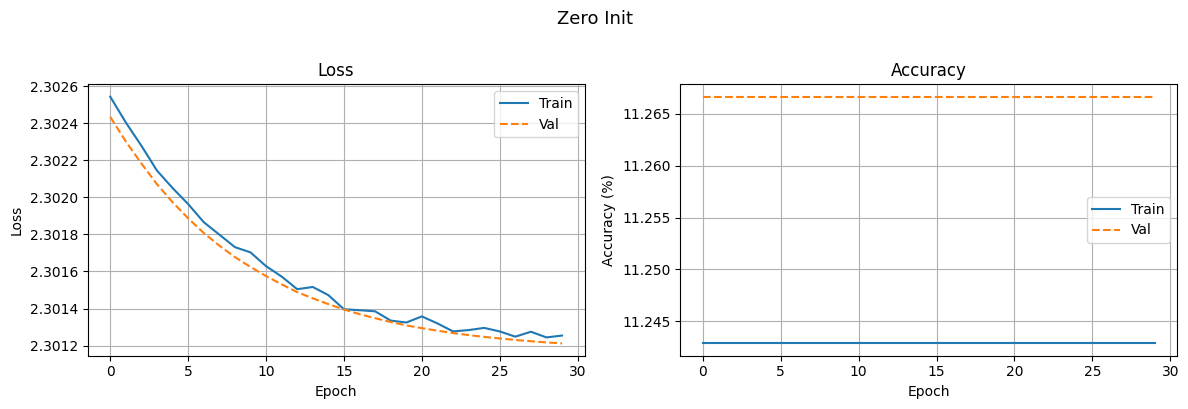

In [91]:
print('Zero init')
net_zero = NeuralNet(init_fn=init_zero)
hist_zero = train(net_zero, X_train, Y_train, y_train, X_val, Y_val, y_val, epochs=30)
plot_history(hist_zero, 'Zero Init')

Random init std=0.01
Epoch   1 | Train loss 2.3025 acc 11.2% | Val loss 2.3024 acc 11.3%
Epoch  10 | Train loss 2.3013 acc 11.2% | Val loss 2.3012 acc 11.3%
Epoch  20 | Train loss 2.3003 acc 11.2% | Val loss 2.3003 acc 11.3%
Epoch  30 | Train loss 2.2989 acc 11.2% | Val loss 2.2987 acc 11.3%


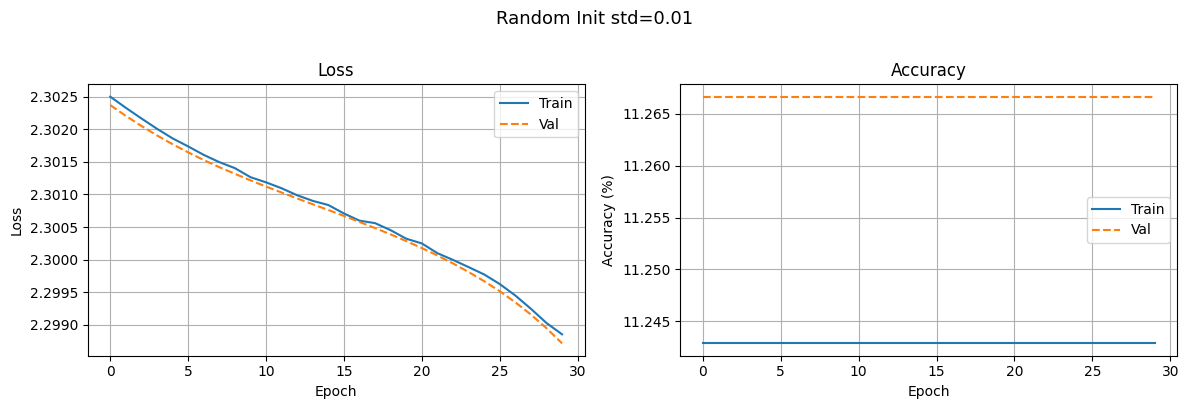

In [103]:
print('Random init std=0.01')
net_random = NeuralNet(init_fn=init_random)
hist_random = train(net_random, X_train, Y_train, y_train, X_val, Y_val, y_val, epochs=30)
plot_history(hist_random, 'Random Init std=0.01')

Random init std=0.1
Epoch   1 | Train loss 10.1491 acc 66.5% | Val loss 6.7241 acc 65.0%
Epoch  10 | Train loss 2.5031 acc 85.3% | Val loss 3.5218 acc 79.1%
Epoch  20 | Train loss 1.4102 acc 88.5% | Val loss 3.2068 acc 80.5%
Epoch  30 | Train loss 0.8618 acc 91.8% | Val loss 3.0718 acc 80.8%


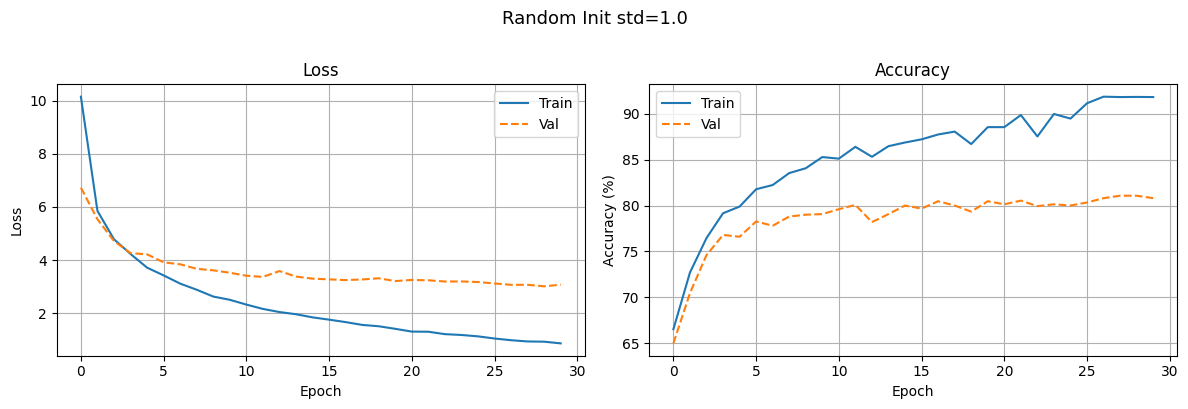

In [104]:
print('Random init std=0.1')
net_random_1 = NeuralNet(init_fn=init_random_1)
hist_random_1 = train(net_random_1, X_train, Y_train, y_train, X_val, Y_val, y_val, epochs=30)
plot_history(hist_random_1, 'Random Init std=1.0')

Xavier init
Epoch   1 | Train loss 2.2116 acc 40.2% | Val loss 2.0870 acc 41.6%
Epoch  10 | Train loss 0.5746 acc 86.7% | Val loss 0.5579 acc 86.7%
Epoch  20 | Train loss 0.3767 acc 90.3% | Val loss 0.3885 acc 89.4%
Epoch  30 | Train loss 0.3137 acc 91.5% | Val loss 0.3391 acc 90.4%


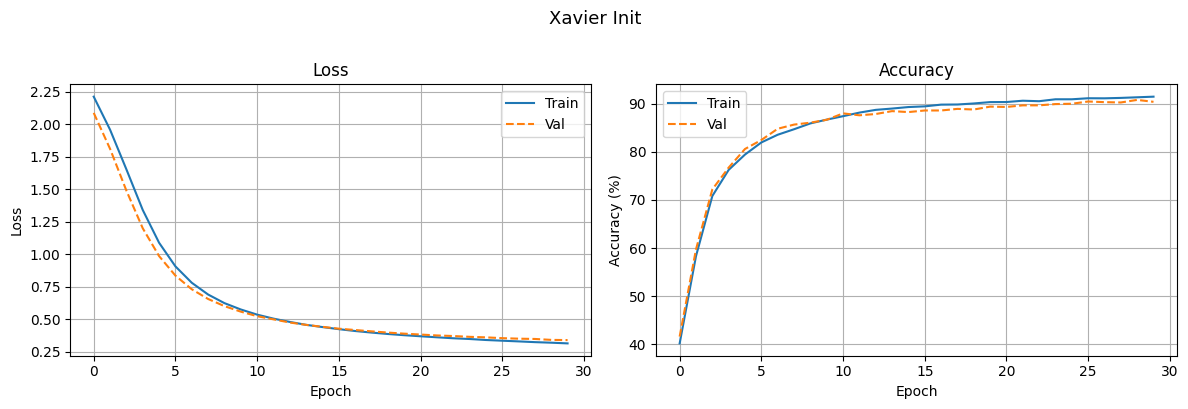

In [105]:
print('Xavier init')
net_xavier = NeuralNet(init_fn=init_xavier)
hist_xavier = train(net_xavier, X_train, Y_train, y_train, X_val, Y_val, y_val, epochs=30)
plot_history(hist_xavier, 'Xavier Init')

He init
Epoch   1 | Train loss 2.2048 acc 38.8% | Val loss 2.0344 acc 39.4%
Epoch  10 | Train loss 0.5486 acc 86.9% | Val loss 0.5326 acc 87.5%
Epoch  20 | Train loss 0.3692 acc 89.9% | Val loss 0.3849 acc 90.3%
Epoch  30 | Train loss 0.3042 acc 91.5% | Val loss 0.3321 acc 90.9%


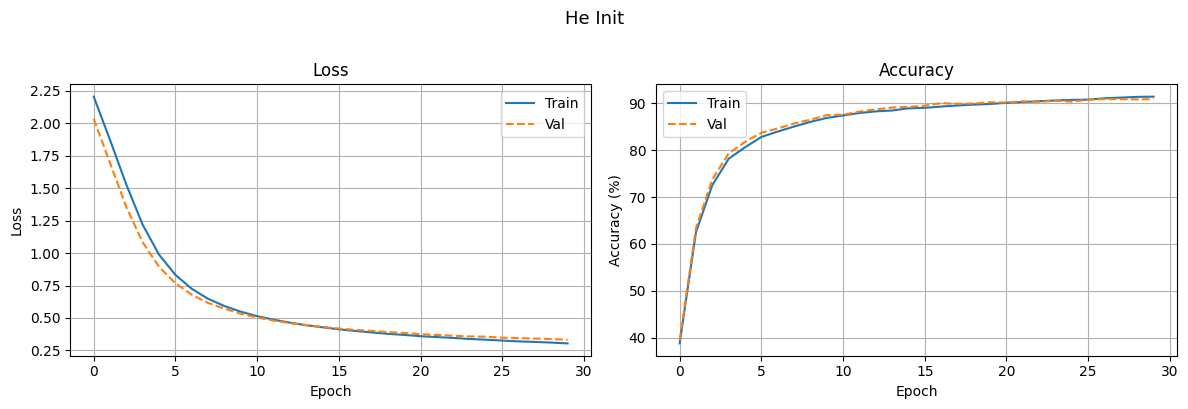

In [106]:
print('He init')
net_he = NeuralNet(init_fn=init_he)
hist_he = train(net_he, X_train, Y_train, y_train, X_val, Y_val, y_val, epochs=30)
plot_history(hist_he, 'He Init')

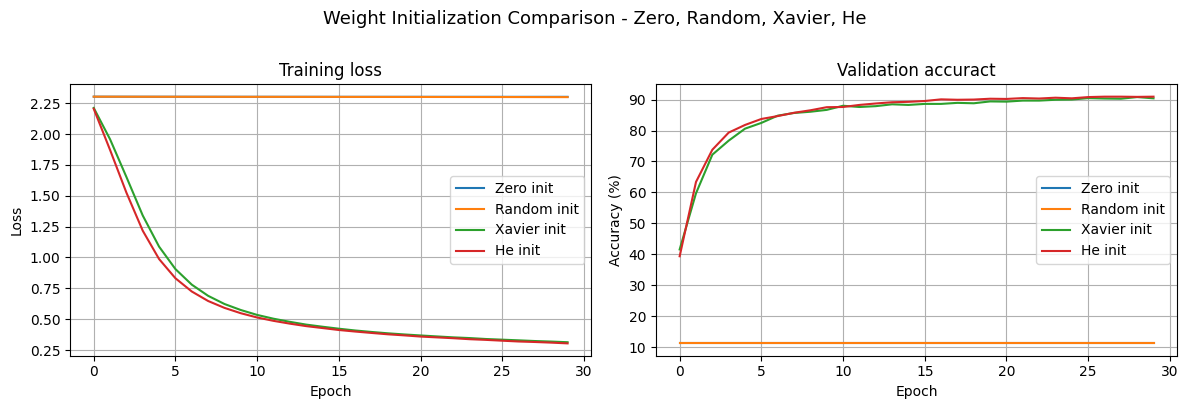

/Final validation accuracy:
 Zero init      : 11.3 %
 Random init    : 11.3 %
 Xavier init    : 90.4 %
 He init        : 90.9 %


In [107]:
# side by side comparison

results = {
    'Zero init': hist_zero,
    'Random init': hist_random,
    'Xavier init': hist_xavier,
    'He init': hist_he
}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

for name, h in results.items():
  ax1.plot(h['train_loss'], label=name)
  ax2.plot(h['val_acc'], label=name)

ax1.set_title('Training loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')

ax2.set_title('Validation accuract')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')

for ax in (ax1, ax2):
  ax.legend()
  ax.grid(True)

plt.suptitle('Weight Initialization Comparison - Zero, Random, Xavier, He', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

print('/Final validation accuracy:')
for name, h in results.items():
  print(f' {name:15s}: {h['val_acc'][-1]:.1f} %')

## Why Zero Init and Random Init (std=0.01) overlap in the plot

Both curves flatline at ~10% accuracy — random chance for 10 classes — and sit on top of each other in the graph. The reasons are different, but the outcome is the same: **no learning happens in either case**.

**Zero init** fails because of the symmetry problem. Every neuron starts identical, computes the same output, receives the same gradient, and updates by the same amount. They are permanently locked together — the network behaves as if it has one neuron per layer regardless of width.

**Random init (std=0.01)** fails for a completely different reason. The weights are not zero, so symmetry is broken — but they are so small that the signal dies before it reaches the output. Each layer multiplies the activations by weights close to zero, shrinking the signal a little more each time:

```
Input std:        1.000
After layer 1:    0.008
After layer 2:    0.0003
After layer 3:    0.000009
After layer 4:    0.0000002   ← effectively zero
```

By the time the signal reaches the output it carries no information. The loss gradient flowing backwards is equally tiny, so weights receive almost no update — training is stuck.

**The key distinction:**

| | Zero init | Random init (std=0.01) |
|---|---|---|
| Symmetry broken? | No | Yes |
| Signal survives forward pass? | No | No |
| Why it fails | All neurons identical | Weights too small, signal vanishes |
| Could more training help? | Never — structurally broken | No — the signal collapses regardless |

Both are defeated by the same root cause: **the forward pass signal does not survive to the output**, so backprop has nothing meaningful to work with. The curves overlap because the failure mode produces the same observable symptom — they just arrive at it through different mechanisms.